#                               HOUSE PRICE
##### Residential property price statistics from different countries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
import os

print(os.getcwd())
os.listdir()

c:\Users\Windows 10\Documents\practicevisualize101\dat_learning\house_price\house_pricenotebooks


['hp_cleaning_visualization.ipynb']

In [21]:
df_h = pd.read_csv("../house_pricedata/nominal-index.csv")
print(df_h.shape)
print(df_h.tail(100))

(12627, 3)
             date        country   price
12527  2017-06-30         Greece   63.15
12528  2017-06-30  Hong Kong SAR  221.00
12529  2017-06-30        Croatia   94.64
12530  2017-06-30        Hungary  131.52
12531  2017-06-30      Indonesia  147.26
...           ...            ...     ...
12622  2017-09-30       Thailand  128.52
12623  2017-09-30         Turkey  244.55
12624  2017-09-30  United States     NaN
12625  2017-09-30      Euro area     NaN
12626  2017-09-30   South Africa  143.11

[100 rows x 3 columns]


country

In [ ]:
print(df_h["country"].unique())
len(df_h["country"].unique())

['Emerging market economies' 'Advanced economies' 'United Arab Emirates'
 'Austria' 'Australia' 'Belgium' 'Bulgaria' 'Brazil' 'Canada'
 'Switzerland' 'Chile' 'China' 'Colombia' 'Cyprus' 'Czech Republic'
 'Germany' 'Denmark' 'Estonia' 'Spain' 'Finland' 'France' 'United Kingdom'
 'Greece' 'Hong Kong SAR' 'Croatia' 'Hungary' 'Indonesia' 'Ireland'
 'Israel' 'India' 'Iceland' 'Italy' 'Japan' 'Korea' 'Lithuania'
 'Luxembourg' 'Latvia' 'Morocco' 'Macedonia, FYR' 'Malta' 'Mexico'
 'Malaysia' 'Netherlands' 'Norway' 'New Zealand' 'Peru' 'Philippines'
 'Poland' 'Portugal' 'Romania' 'Serbia' 'Russia' 'Sweden' 'Singapore'
 'Slovenia' 'Slovak Republic' 'Thailand' 'Turkey' 'United States'
 'Euro area' 'South Africa']


61

in the first few year during(1966-2000) information about price where missing
so the data on the very first year 

In [ ]:
df_h1=df_h[df_h["price"].notna()]
df_h1["year"] = df_h1["date"].str[:4]
year_count=df_h1["year"].value_counts().sort_index()
#.str
#.value_counts
#sort_index()
print(f"mean={df_h1["year"].value_counts().mean()}")
print(f"median={df_h1["year"].value_counts().median()}")
print(f"mode={df_h1["year"].value_counts().mode()}")


mean=87.71153846153847
median=50.0
mode=0    244
Name: count, dtype: int64


C:\Users\Windows 10\AppData\Local\Temp\ipykernel_23760\2394380920.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_h1["year"] = df_h1["date"].str[:4]


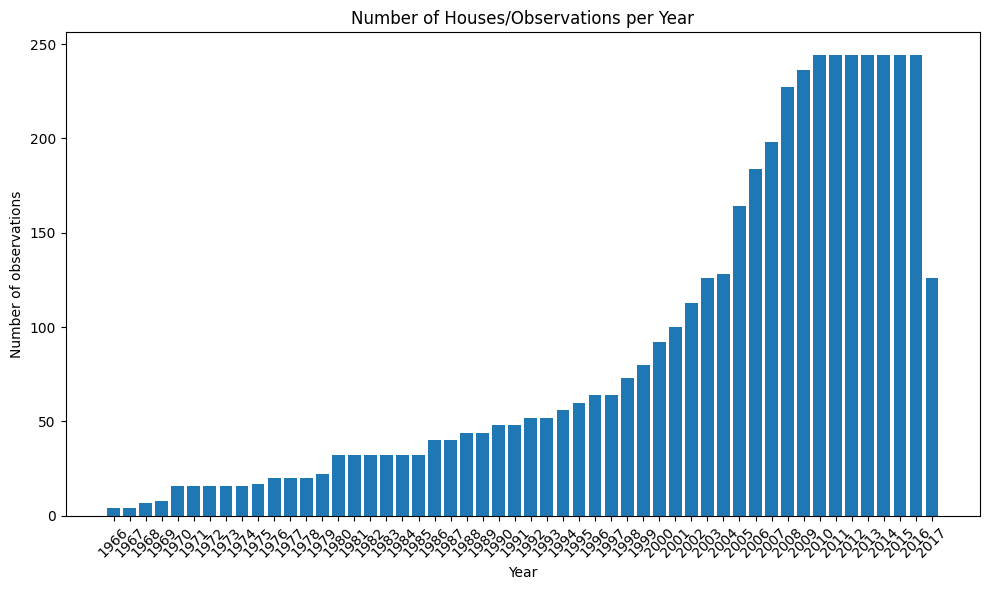

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(year_count.index, year_count.values)
plt.xticks(year_count.index,rotation=45)
plt.title("Number of Houses/Observations per Year")
plt.xlabel("Year")
plt.ylabel("Number of observations")

plt.tight_layout()
plt.show()

decided to use a data that have number of observation more than 100

turn out to be 2002-2017 data

In [ ]:
valid_years = year_count[year_count > 100].index
print(valid_years)
df_ht = df_h1[df_h1["year"].isin(valid_years)].copy()
print(df_ht)
print(f"mean={df_ht["year"].value_counts().mean()}")
print(f"median={df_ht["year"].value_counts().median()}")
print(f"mode={df_ht["year"].value_counts().mode()}")


Index(['2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017'],
      dtype='object', name='year')
             date       country   price  year
8787   2002-03-31       Austria   79.91  2002
8791   2002-03-31        Brazil   28.83  2002
8792   2002-03-31        Canada   53.49  2002
8793   2002-03-31   Switzerland   75.17  2002
8794   2002-03-31         Chile   74.09  2002
...           ...           ...     ...   ...
12608  2017-09-30   Netherlands  102.44  2017
12609  2017-09-30        Norway  146.19  2017
12622  2017-09-30      Thailand  128.52  2017
12623  2017-09-30        Turkey  244.55  2017
12626  2017-09-30  South Africa  143.11  2017

[3210 rows x 4 columns]
mean=200.625
median=231.5
mode=0    244
Name: count, dtype: int64


data came from which country

In [ ]:
print(df_ht["country"].unique())
df_ht["country"].value_counts().sort_values()

['Austria' 'Brazil' 'Canada' 'Switzerland' 'Chile' 'Colombia' 'Cyprus'
 'France' 'United Kingdom' 'Hong Kong SAR' 'Indonesia' 'Israel' 'Iceland'
 'Italy' 'Korea' 'Lithuania' 'Malaysia' 'Netherlands' 'Norway'
 'New Zealand' 'Peru' 'Serbia' 'Russia' 'Sweden' 'Singapore'
 'United States' 'Euro area' 'South Africa' 'Denmark'
 'United Arab Emirates' 'Germany' 'Australia' 'Belgium' 'Bulgaria'
 'Estonia' 'Finland' 'Ireland' 'Macedonia, FYR' 'Malta' 'Mexico' 'China'
 'Spain' 'Greece' 'Latvia' 'Morocco' 'Slovak Republic' 'Hungary'
 'Luxembourg' 'Slovenia' 'Emerging market economies' 'Advanced economies'
 'Czech Republic' 'Croatia' 'Philippines' 'Portugal' 'Thailand' 'Japan'
 'India' 'Romania' 'Poland' 'Turkey']


country
Poland          30
Turkey          31
India           34
Romania         34
Japan           36
                ..
Iceland         63
Switzerland     63
Korea           63
South Africa    63
Norway          63
Name: count, Length: 61, dtype: int64

year
2002     59.942124
2003     64.430397
2004     70.181562
2005     78.514329
2006     88.250761
2007     98.156717
2008    102.743789
2009     97.356653
2010     99.999918
2011    102.434672
2012    105.442992
2013    109.863033
2014    115.396803
2015    120.922131
2016    127.045574
2017    134.093175
Name: price, dtype: float64


Text(0.5, 0, 'year')

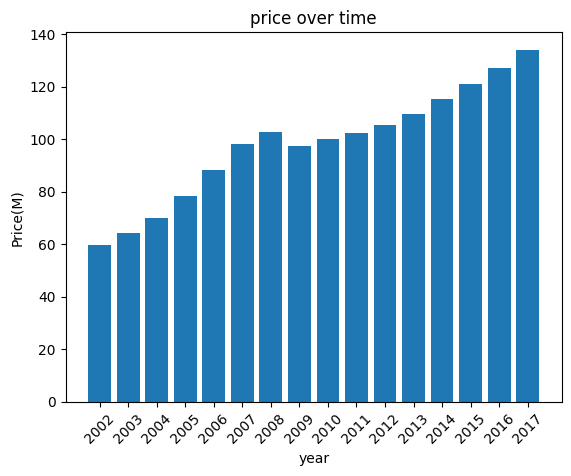

In [ ]:
avg_price = df_ht.groupby("year")["price"].mean()
print(avg_price)

plt.bar(avg_price.index,avg_price.values)
plt.title("price over time")
plt.ylabel("Price(M)")
plt.xticks(avg_price.index,rotation=45)
plt.xlabel("year")

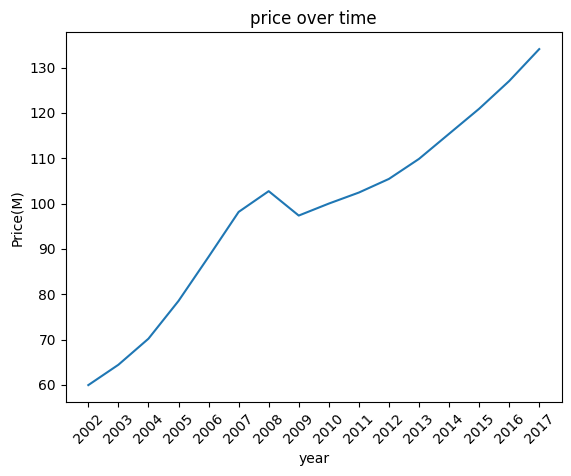

In [ ]:
plt.grid()
plt.plot(avg_price.index,avg_price.values)
plt.grid()
plt.title("price over time")
plt.ylabel("Price(M)")
plt.xticks(avg_price.index,rotation=45)
plt.xlabel("year")
plt.show()

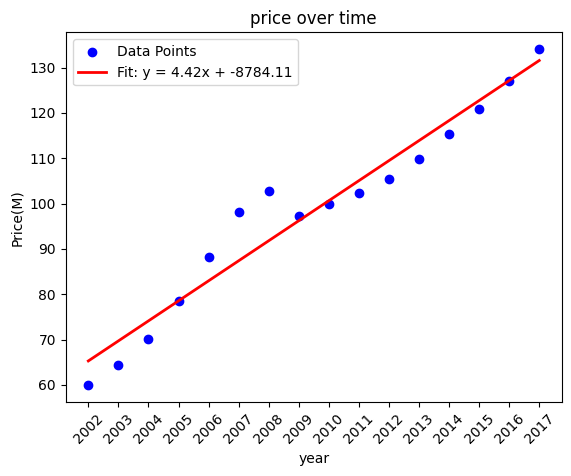

In [ ]:
x_numeric = avg_price.index.astype(float) 
y_values = avg_price.values
#x-is string before(doo didi)
plt.scatter(avg_price.index, y_values, color='blue', label='Data Points')


m, b = np.polyfit(x_numeric, y_values, 1)


plt.plot(avg_price.index, m * x_numeric + b, color='red', linewidth=2, label=f'Fit: y = {m:.2f}x + {b:.2f}')

plt.title("price over time")
plt.ylabel("Price(M)")
plt.xticks(avg_price.index, rotation=45)
plt.xlabel("year")
plt.legend()
plt.show()


country

country
Advanced economies      106.832821
Australia                95.949643
Austria                 103.084032
Belgium                 100.478400
Brazil                   91.095323
                           ...    
Thailand                111.768718
Turkey                  156.450323
United Arab Emirates    113.525254
United Kingdom           99.521290
United States           115.176935
Name: price, Length: 61, dtype: float64


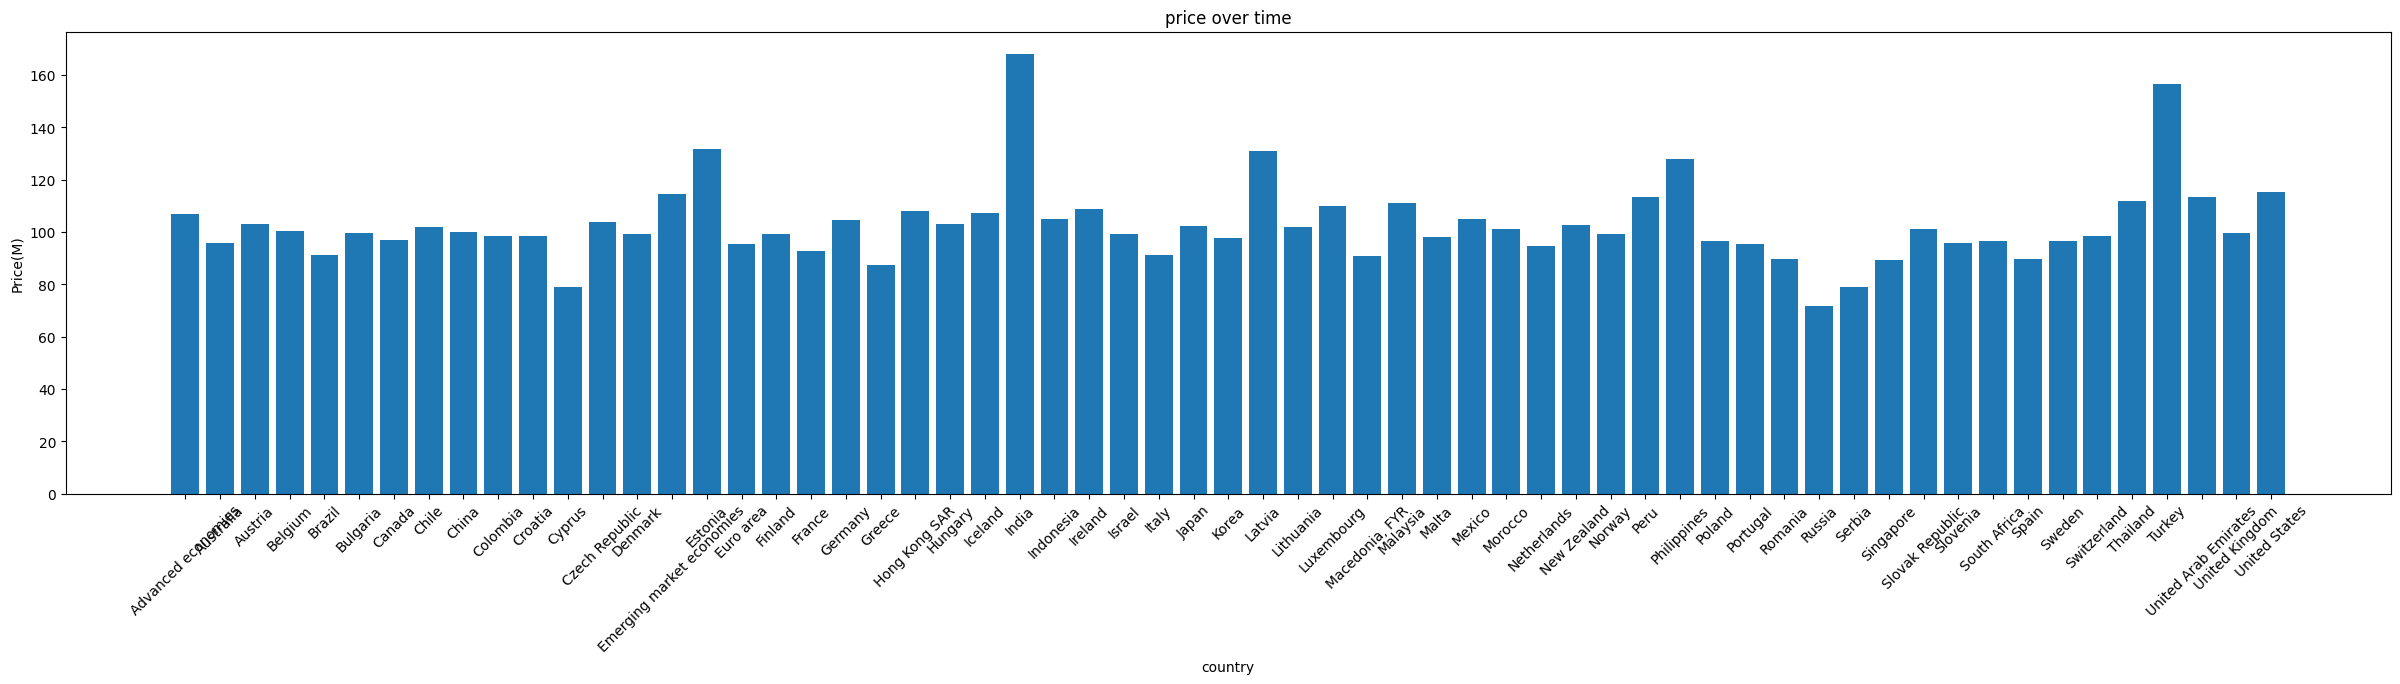

In [ ]:
avgc_price = df_ht.groupby("country")["price"].mean()
print(avgc_price)
plt.figure(figsize=(30, 6))
plt.bar(avgc_price.index,avgc_price.values)
plt.title("price over time")
plt.ylabel("Price(M)")
plt.xticks(avgc_price.index,rotation=45)
plt.xlabel("country")
plt.show()

in korea,thailand

In [ ]:
df_ht_korea=df_ht[df_ht["country"]=="Korea"].copy()
print(df_ht_korea)
df_ht_thai=df_ht[df_ht["country"]=="Thailand"].copy()
print(df_ht_thai)

             date country   price  year
8817   2002-03-31   Korea   69.01  2002
8878   2002-06-30   Korea   71.74  2002
8939   2002-09-30   Korea   74.24  2002
9000   2002-12-31   Korea   76.31  2002
9061   2003-03-31   Korea   76.79  2003
...           ...     ...     ...   ...
12355  2016-09-30   Korea  116.19  2016
12416  2016-12-31   Korea  116.85  2016
12477  2017-03-31   Korea  117.05  2017
12538  2017-06-30   Korea  117.22  2017
12599  2017-09-30   Korea  117.87  2017

[63 rows x 4 columns]
             date   country   price  year
10304  2008-03-31  Thailand   87.11  2008
10365  2008-06-30  Thailand   90.53  2008
10426  2008-09-30  Thailand   94.82  2008
10487  2008-12-31  Thailand   97.46  2008
10548  2009-03-31  Thailand   95.51  2009
10609  2009-06-30  Thailand   96.19  2009
10670  2009-09-30  Thailand   97.75  2009
10731  2009-12-31  Thailand   99.90  2009
10792  2010-03-31  Thailand   98.05  2010
10853  2010-06-30  Thailand   98.83  2010
10914  2010-09-30  Thailand  101.46

In [ ]:
avgkorea_price = df_ht_korea.groupby("year")["price"].mean()
print(avgkorea_price)
avgthai_price = df_ht_thai.groupby("year")["price"].mean()
print(avgthai_price)

year
2002     72.8250
2003     79.3925
2004     80.2900
2005     80.9375
2006     85.9225
2007     93.6775
2008     97.4425
2009     97.6300
2010     99.9975
2011    105.2650
2012    108.2675
2013    107.7925
2014    109.4250
2015    113.1050
2016    116.1075
2017    117.3800
Name: price, dtype: float64
year
2008     92.4800
2009     97.3375
2010    100.0000
2011    104.2725
2012    107.7400
2013    116.1875
2014    122.8500
2015    125.9750
2016    127.7350
2017    126.8900
Name: price, dtype: float64


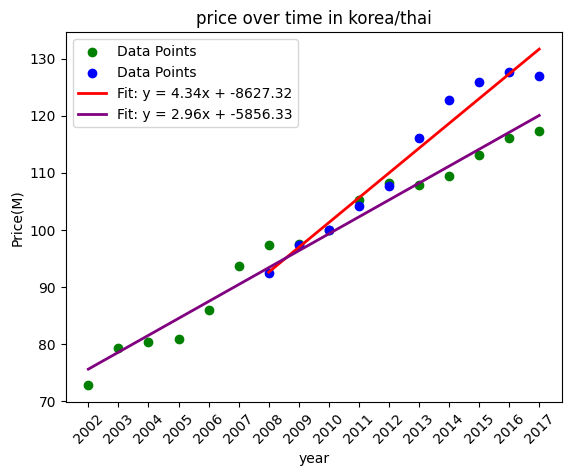

In [ ]:
x_numeric = avgkorea_price.index.astype(float) 
y_values = avgkorea_price.values
plt.scatter(avgkorea_price.index, y_values, color='green', label='Data Points')


m, b = np.polyfit(x_numeric, y_values, 1)


x_numeric1 = avgthai_price.index.astype(float) 
y_values1 = avgthai_price.values
plt.scatter(avgthai_price.index, y_values1, color='blue', label='Data Points')


m1, b1 = np.polyfit(x_numeric1, y_values1, 1)


plt.plot(avgthai_price.index, m1 * x_numeric1 + b1, color='red', linewidth=2, label=f'Fit: y = {m1:.2f}x + {b1:.2f}')

plt.plot(avgkorea_price.index, m * x_numeric + b, color='purple', linewidth=2, label=f'Fit: y = {m:.2f}x + {b:.2f}')
plt.title("price over time in korea/thai")
plt.ylabel("Price(M)")
plt.xticks(avgkorea_price.index, rotation=45)
plt.xlabel("year")
plt.legend()
plt.show()